In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df= pd.read_csv('telco_churn.csv')

In [6]:
print("Shape:",df.shape)

Shape: (7043, 21)


In [7]:
print("\nFirst 5 rows:")


First 5 rows:


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique values per column:\n", df.nunique())

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBillin

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


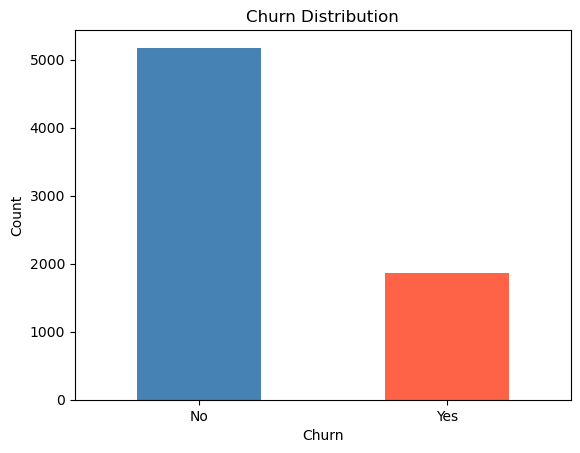

In [12]:
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True)*100)
df['Churn'].value_counts().plot(kind='bar',color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [13]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [14]:
print(df['TotalCharges'].isnull().sum())

11


In [15]:
print(df[df['TotalCharges'].isnull()])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

In [16]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [17]:
print("NaN in TotalCharges after fix:",df['TotalCharges'].isnull().sum())
print("TotalCharges dtypes:",df['TotalCharges'].dtype)

NaN in TotalCharges after fix: 0
TotalCharges dtypes: float64


In [25]:

print("New shape:",df.shape)
print("Columns remaining:", df.columns.tolist())

New shape: (7043, 20)
Columns remaining: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


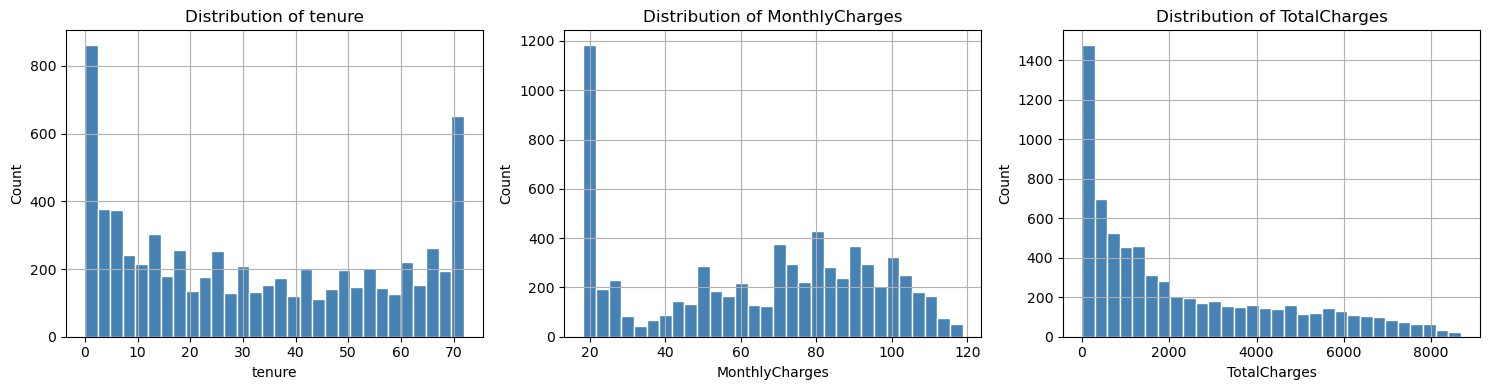

In [27]:
numerical_cols =['tenure','MonthlyCharges','TotalCharges']
fig,axes = plt.subplots(1,3, figsize=(15,4))

for i,col in enumerate(numerical_cols):
    df[col].hist(bins=30,ax=axes[i],color='steelblue',edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

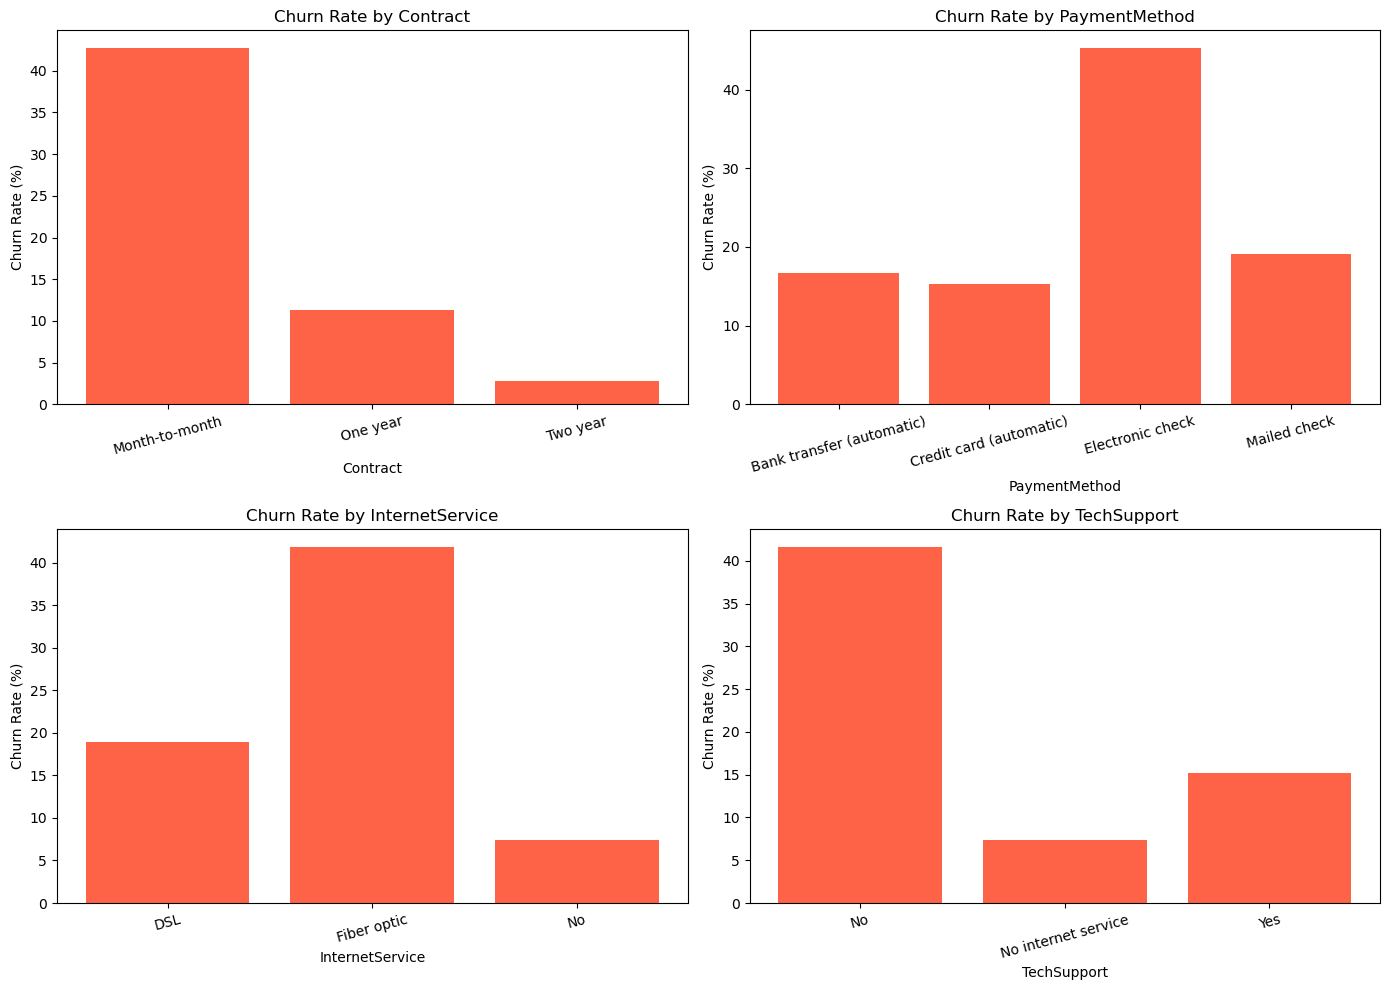

In [35]:
categorical_cols=['Contract','PaymentMethod','InternetService','TechSupport']

fig,axes= plt.subplots(2,2, figsize=(14,10))
axes=axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns=[col,'ChurnRate']
    axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],color='tomato')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x',rotation=15)

plt.tight_layout()
plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-207' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at C:\Users\bharv\anaconda3\envs\churn_pipeline\lib\site-packages\ipykernel\utils.py:76> wait_for=<Task pending name='Task-208' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\bharv\anaconda3\envs\churn_pipeline\lib\site-packages\ipykernel\utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\bharv\anaconda3\envs\churn_pipeline\lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\bharv\anaconda3\envs\churn_pipeline\lib\site-packages\cycler\__init__.py:441: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  for k in keys:
Task was destroyed but it is pending!
task: <Task pending name='Task-208' coro=<_async_in_context.<locals>.preserve_context() running at C:\Users\bharv\anaconda3\envs\churn_pipeline\lib\site-packages\ipykernel\

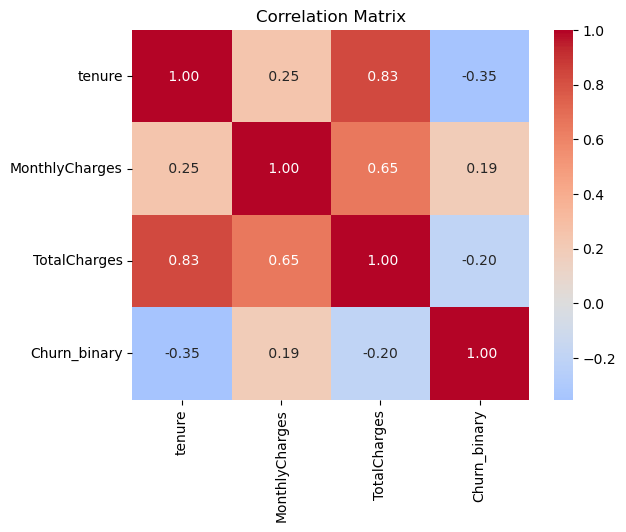

In [36]:
df_temp=df.copy()
df_temp['Churn_binary']= (df_temp['Churn']=='Yes').astype(int)

corr=df_temp[['tenure','MonthlyCharges','TotalCharges','Churn_binary']].corr()

sns.heatmap(corr,annot=True, fmt=' .2f',cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [37]:
df.to_csv('telco_churn_cleaned.csv',index=False)
print("Saved Successfully.")
print("Final shape:", df.shape)

Saved Successfully.
Final shape: (7043, 20)
